# CTU-13 Dataset EDA

Exploratory data analysis for all 13 CTU-13 botnet scenarios.
Requires flow files under `data/raw/` (set `DATA_DIR` below to override).

In [1]:
# Ensure gbd_ctu is importable when running without pip install -e .
import sys, os
from pathlib import Path as _Path
_repo_root = _Path("__file__").resolve().parents[1] if "__file__" in dir() else _Path.cwd().parent
_src = _repo_root / "src"
if str(_src) not in sys.path and _src.exists():
    sys.path.insert(0, str(_src))

# Synthetic-data fallback ─────────────────────────────────────────────────────
# When DATA_DIR has no CTU-13 flow files (e.g. in CI), this cell generates
# 13 deterministic synthetic scenario DataFrames so every subsequent cell runs
# end-to-end without internet access or real CTU-13 data.
#
# If real data exists the patching is skipped and the loader uses disk files.

import numpy as np
import pandas as pd
from pathlib import Path
from unittest.mock import MagicMock

from gbd_ctu.data.ctu13_loader import CTU13Loader

DATA_DIR = Path("data/raw")  # override if needed

_real_data_available = DATA_DIR.exists() and any(DATA_DIR.rglob("*.binetflow"))

def _make_synthetic_frame(sid: int, seed: int) -> pd.DataFrame:
    """Deterministic synthetic normalised flow frame for scenario sid."""
    rng = np.random.default_rng(seed)
    n = int(rng.integers(2000, 5000))
    n_bot = int(n * rng.uniform(0.03, 0.20))
    src_pool = [f"10.{sid}.0.{i}" for i in range(20)]
    dst_pool = [f"192.168.{sid}.{i}" for i in range(30)]
    ports = [80, 443, 22, 53, 8080, 3389, 1433]
    base = pd.Timestamp("2011-08-10 09:00:00")
    rows = []
    for i in range(n):
        lbl = "Botnet" if i < n_bot else ("Normal" if i < n_bot + int(n*0.3) else "Background")
        rows.append({
            "start_time": str(base + pd.Timedelta(seconds=int(rng.integers(0, 7200)))),
            "duration":   float(rng.uniform(0, 120)),
            "src_addr":   str(rng.choice(src_pool)),
            "dst_addr":   str(rng.choice(dst_pool)),
            "dst_port":   int(rng.choice(ports)),
            "label":      lbl,
            "label_binary": 1 if lbl == "Botnet" else 0,
        })
    return pd.DataFrame(rows)

if not _real_data_available:
    print("No CTU-13 data found — running in SYNTHETIC mode")
    _synthetic_frames = {sid: _make_synthetic_frame(sid, sid) for sid in range(1, 14)}
    _loader_mock = MagicMock(spec=CTU13Loader)
    _loader_mock.available_scenarios.return_value = list(range(1, 14))
    _loader_mock.load_scenario.side_effect = lambda sid: _synthetic_frames[sid]
    _loader_mock.load_all.return_value = _synthetic_frames
else:
    print(f"Real CTU-13 data found in {DATA_DIR}")
    _loader_mock = None


/home/misa/miniforge3/lib/python3.13/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


No CTU-13 data found — running in SYNTHETIC mode


In [2]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from gbd_ctu.data.ctu13_loader import CTU13Loader, dataset_statistics_table, scenario_statistics

DATA_DIR = Path('data/raw')   # override if needed
OUTPUT_DIR = Path('results/eda')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Data dir : {DATA_DIR.resolve()}')
print(f'Output dir: {OUTPUT_DIR.resolve()}')

Data dir : /home/misa/cybersecurity/notebooks/data/raw
Output dir: /home/misa/cybersecurity/notebooks/results/eda


In [3]:
# Cell 2 — Build statistics table
from gbd_ctu.data.ctu13_loader import CTU13Loader, dataset_statistics_table, scenario_statistics

loader = _loader_mock if _loader_mock is not None else CTU13Loader(data_root=DATA_DIR)
stats_df = dataset_statistics_table(loader)

display_cols = [
    'scenario_id', 'family', 'total_flows',
    'botnet_flows', 'botnet_frac',
    'normal_flows', 'background_flows',
    'unique_src_ips', 'unique_dst_ips',
    'botnet_host_ips', 'unique_dst_ports',
    'mean_duration', 'max_duration',
]
display_cols = [c for c in display_cols if c in stats_df.columns]
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
stats_df[display_cols]


,scenario_id,family,total_flows,botnet_flows,botnet_frac,normal_flows,background_flows,unique_src_ips,unique_dst_ips,botnet_host_ips,unique_dst_ports,mean_duration,max_duration
0,1,Neris,3419,655,0.1916,1025,1739,20,30,20,7,60.7243,119.9733
1,2,Neris,4512,364,0.0807,1353,2795,20,30,20,7,60.0149,119.9950
2,3,Rbot,4434,311,0.0701,1330,2793,20,30,20,7,59.2223,119.9966
3,4,Rbot,4179,488,0.1168,1253,2438,20,30,20,7,59.7949,119.9390
4,5,Virut,4012,671,0.1672,1203,2138,20,30,20,7,59.8743,119.9265
5,6,Virut,3335,294,0.0882,1000,2041,20,30,20,7,60.0168,119.9271
6,7,Menti,4834,882,0.1825,1450,2502,20,30,20,7,59.7757,119.9276
7,8,Sogou,4158,822,0.1977,1247,2089,20,30,20,7,60.7395,119.9553
8,9,Neris,3264,257,0.0787,979,2028,20,30,20,7,59.2084,119.9974
9,10,Murlo,4329,282,0.0651,1298,2749,20,30,20,7,60.1091,119.9795


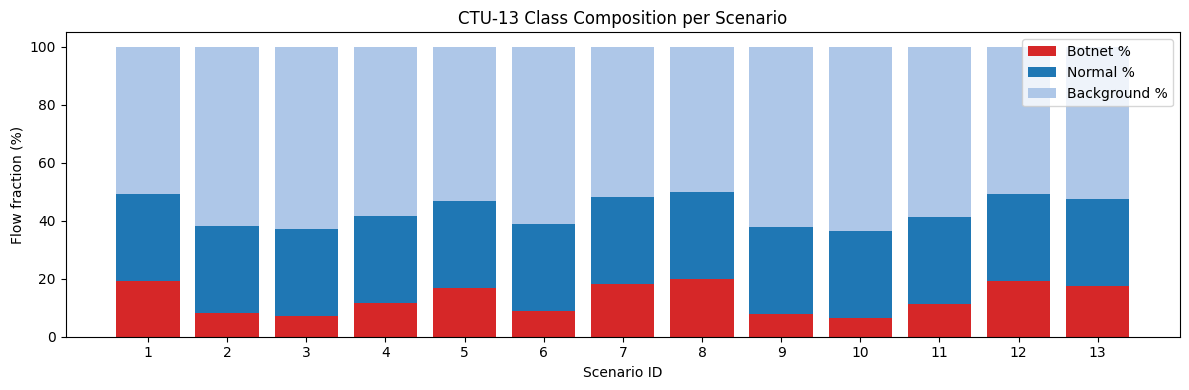

In [4]:
# Cell 3 — Per-scenario class imbalance bar chart
fig, ax = plt.subplots(figsize=(12, 4))
x = stats_df['scenario_id'].astype(str)
ax.bar(x, stats_df['botnet_frac'] * 100, label='Botnet %', color='#d62728')
ax.bar(x, stats_df['normal_frac'] * 100,
       bottom=stats_df['botnet_frac'] * 100, label='Normal %', color='#1f77b4')
ax.bar(x, stats_df['background_frac'] * 100,
       bottom=(stats_df['botnet_frac'] + stats_df['normal_frac']) * 100,
       label='Background %', color='#aec7e8')
ax.set_xlabel('Scenario ID')
ax.set_ylabel('Flow fraction (%)')
ax.set_title('CTU-13 Class Composition per Scenario')
ax.legend(loc='upper right')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'class_imbalance.png', dpi=300, bbox_inches='tight')
plt.show()

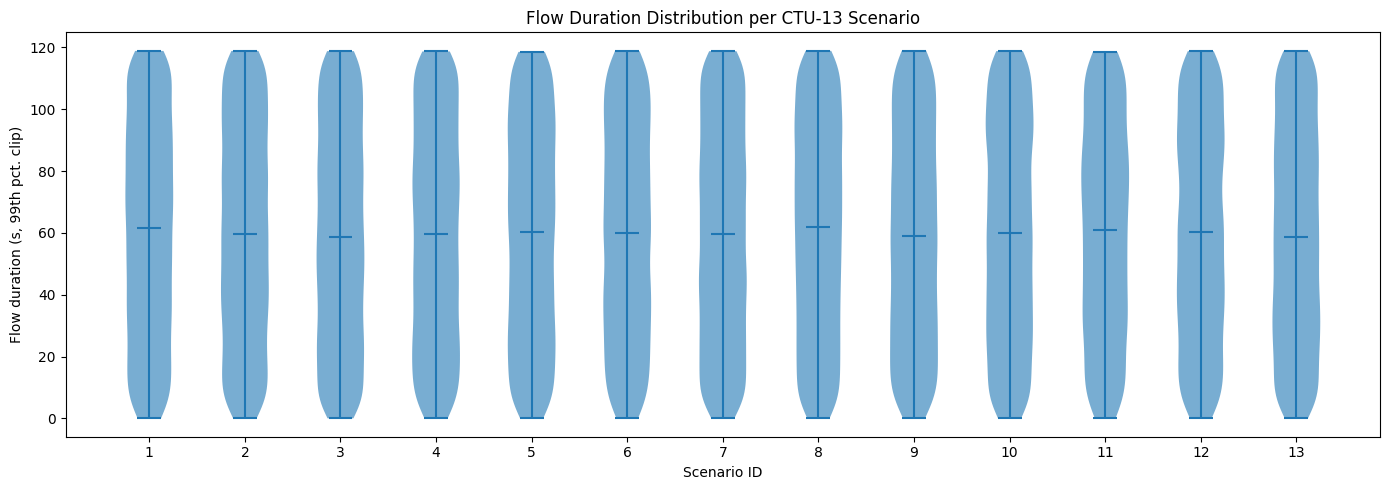

In [5]:
# Cell 4 — Flow duration distributions (violin plot)
all_frames = loader.load_all()   # loads all scenarios
duration_data = {
    sid: frame['duration'].clip(0, frame['duration'].quantile(0.99)).values
    for sid, frame in all_frames.items()
}
labels = [str(k) for k in sorted(duration_data)]
data   = [duration_data[k] for k in sorted(duration_data)]

fig, ax = plt.subplots(figsize=(14, 5))
parts = ax.violinplot(data, showmedians=True)
for pc in parts['bodies']:
    pc.set_facecolor('#1f77b4')
    pc.set_alpha(0.6)
ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels)
ax.set_xlabel('Scenario ID')
ax.set_ylabel('Flow duration (s, 99th pct. clip)')
ax.set_title('Flow Duration Distribution per CTU-13 Scenario')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'flow_duration_violin.png', dpi=300, bbox_inches='tight')
plt.show()

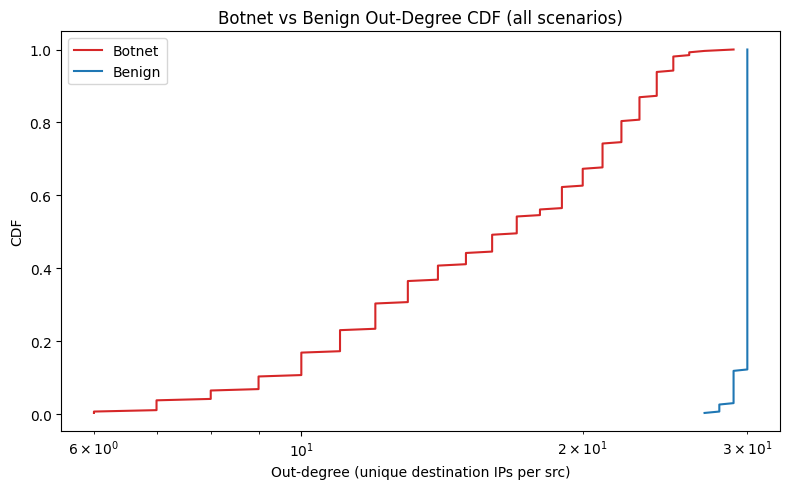

In [6]:
# Cell 5 — Botnet vs benign degree CDF (using unique_dst_count per src_addr)
# Aggregate all scenarios for a combined view
all_rows = pd.concat(all_frames.values(), ignore_index=True)
degree = (
    all_rows.groupby(['src_addr', 'label_binary'])['dst_addr']
    .nunique()
    .reset_index()
    .rename(columns={'dst_addr': 'out_degree'})
)
botnet_deg  = degree[degree['label_binary'] == 1]['out_degree'].values
benign_deg  = degree[degree['label_binary'] == 0]['out_degree'].values

fig, ax = plt.subplots(figsize=(8, 5))
for vals, label, color in [
    (botnet_deg, 'Botnet', '#d62728'),
    (benign_deg, 'Benign', '#1f77b4'),
]:
    sorted_vals = np.sort(vals)
    cdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
    ax.plot(sorted_vals, cdf, label=label, color=color)
ax.set_xscale('log')
ax.set_xlabel('Out-degree (unique destination IPs per src)')
ax.set_ylabel('CDF')
ax.set_title('Botnet vs Benign Out-Degree CDF (all scenarios)')
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'degree_cdf.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
# Cell 6 — Export LaTeX table
from pathlib import Path
latex_cols = [
    'scenario_id', 'family', 'total_flows',
    'botnet_flows', 'botnet_frac',
    'unique_src_ips', 'botnet_host_ips',
    'mean_duration',
]
latex_cols = [c for c in latex_cols if c in stats_df.columns]
tex = stats_df[latex_cols].to_latex(
    index=False,
    float_format='%.4f',
    na_rep='—',
    caption='CTU-13 per-scenario dataset statistics.',
    label='tab:dataset_stats',
)
# Write to results/dataset_stats.tex (canonical path) AND results/eda/dataset_stats.tex
results_root = Path('results')
results_root.mkdir(parents=True, exist_ok=True)
tex_path_root = results_root / 'dataset_stats.tex'
tex_path_root.write_text(tex, encoding='utf-8')
tex_path_eda = Path('results/eda/dataset_stats.tex')
tex_path_eda.parent.mkdir(parents=True, exist_ok=True)
tex_path_eda.write_text(tex, encoding='utf-8')
print(f'LaTeX table written to {tex_path_root} and {tex_path_eda}')
print(tex)


LaTeX table written to results/dataset_stats.tex and results/eda/dataset_stats.tex
\begin{table}
\caption{CTU-13 per-scenario dataset statistics.}
\label{tab:dataset_stats}
\begin{tabular}{rlrrrrrr}
\toprule
scenario_id & family & total_flows & botnet_flows & botnet_frac & unique_src_ips & botnet_host_ips & mean_duration \\
\midrule
1 & Neris & 3419 & 655 & 0.1916 & 20 & 20 & 60.7243 \\
2 & Neris & 4512 & 364 & 0.0807 & 20 & 20 & 60.0149 \\
3 & Rbot & 4434 & 311 & 0.0701 & 20 & 20 & 59.2223 \\
4 & Rbot & 4179 & 488 & 0.1168 & 20 & 20 & 59.7949 \\
5 & Virut & 4012 & 671 & 0.1672 & 20 & 20 & 59.8743 \\
6 & Virut & 3335 & 294 & 0.0882 & 20 & 20 & 60.0168 \\
7 & Menti & 4834 & 882 & 0.1825 & 20 & 20 & 59.7757 \\
8 & Sogou & 4158 & 822 & 0.1977 & 20 & 20 & 60.7395 \\
9 & Neris & 3264 & 257 & 0.0787 & 20 & 20 & 59.2084 \\
10 & Murlo & 4329 & 282 & 0.0651 & 20 & 20 & 60.1091 \\
11 & Neris & 2401 & 275 & 0.1145 & 20 & 20 & 60.3931 \\
12 & NSIS.ay & 3838 & 732 & 0.1907 & 20 & 20 & 60.2158 \\
13